# 基于 PyTorch 的乳腺癌良恶性分类

本实验使用 Kaggle Breast Cancer Wisconsin 数据集，对乳腺癌样本进行良性（Benign）和恶性（Malignant）二分类。实验使用 PyTorch 完成模型训练与预测。对比的 4 种分类方法分别是线性分类器、浅层 MLP、深层 MLP 和一维卷积网络。

In [1]:
from pathlib import Path
import pandas as pd
import torch
from IPython.display import Image, display

from breast_cancer_core import (
    MODEL_BUILDERS,
    FEATURE_COLUMNS,
    get_project_root,
    metrics_rows,
    predict_features,
    prepare_split,
    save_all_plots,
    save_best_model,
    save_metrics_csv,
    save_preprocess_stats,
    set_seed,
    train_all_models,
)

pd.set_option('display.max_columns', 40)
project_root = get_project_root()
data_path = project_root / '数据集' / 'breast cancer.csv'
results_dir = project_root / 'results'
figure_dir = project_root / '结果图'
seed = 42
set_seed(seed)
print('Project root:', project_root)
print('Data path:', data_path)
print('PyTorch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())

Project root: D:\桌面\机器学习大作业\一.大作业\2代码\2.3乳腺癌分类
Data path: D:\桌面\机器学习大作业\一.大作业\2代码\2.3乳腺癌分类\数据集\breast cancer.csv
PyTorch version: 2.5.1
CUDA available: False


## 1. 数据读取与基本信息

原始数据包含 569 个样本、33 个字段。其中 `diagnosis` 是标签列，`M` 表示恶性，`B` 表示良性。`id` 只是样本编号，`Unnamed: 32` 是全空列，因此训练前删除这两列。

In [2]:
raw_df, cleaned_df, split_data = prepare_split(data_path=data_path, seed=seed)
print('Raw shape:', raw_df.shape)
print('Cleaned shape:', cleaned_df.shape)
print('Feature count:', len(FEATURE_COLUMNS))
print('Missing values after cleaning:', int(cleaned_df.isna().sum().sum()))
print('Label counts:')
print(cleaned_df['diagnosis'].map({0: 'Benign', 1: 'Malignant'}).value_counts())
raw_df.head()

Raw shape: (569, 33)
Cleaned shape: (569, 31)
Feature count: 30
Missing values after cleaning: 0
Label counts:
diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## 2. 数据清洗与特征概览

清洗后保留 30 个数值特征。所有特征来自细胞核半径、纹理、周长、面积、平滑度、凹陷度等统计量。标签被映射为 `B=0`、`M=1`。

In [3]:
summary = cleaned_df[FEATURE_COLUMNS].describe().T[['mean', 'std', 'min', 'max']]
summary.head(10)

,mean,std,min,max
radius_mean,14.127292,3.524049,6.98100,28.11000
texture_mean,19.289649,4.301036,9.71000,39.28000
perimeter_mean,91.969033,24.298981,43.79000,188.50000
area_mean,654.889104,351.914129,143.50000,2501.00000
smoothness_mean,0.096360,0.014064,0.05263,0.16340
compactness_mean,0.104341,0.052813,0.01938,0.34540
concavity_mean,0.088799,0.079720,0.00000,0.42680
concave points_mean,0.048919,0.038803,0.00000,0.20120
symmetry_mean,0.181162,0.027414,0.10600,0.30400
fractal_dimension_mean,0.062798,0.007060,0.04996,0.09744


In [4]:
print('Train samples:', len(split_data.y_train), 'class counts:', torch.bincount(split_data.y_train).tolist())
print('Validation samples:', len(split_data.y_val), 'class counts:', torch.bincount(split_data.y_val).tolist())
print('Test samples:', len(split_data.y_test), 'class counts:', torch.bincount(split_data.y_test).tolist())
print('Standardization mean shape:', tuple(split_data.mean.shape))
print('Standardization std shape:', tuple(split_data.std.shape))

Train samples: 398 class counts: [250, 148]
Validation samples: 86 class counts: [54, 32]
Test samples: 85 class counts: [53, 32]
Standardization mean shape: (30,)
Standardization std shape: (30,)


## 3. 四种 PyTorch 分类模型

实验固定随机种子为 42，使用训练集均值和标准差进行标准化。损失函数为交叉熵，优化器为 Adam。每个模型最多训练 300 轮，并根据验证集 F1-score 进行 early stopping。

In [5]:
for name, builder in MODEL_BUILDERS.items():
    model = builder(input_dim=len(FEATURE_COLUMNS), num_classes=2)
    print('\n' + name)
    print(model)


LinearClassifier
LinearClassifier(
  (net): Linear(in_features=30, out_features=2, bias=True)
)

ShallowMLP
ShallowMLP(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=2, bias=True)
  )
)

DeepMLP
DeepMLP(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): ReLU()
    (10): Linear(in_features=16, out_features=2, bias=True)
  )
)

FeatureCNN1D
FeatureCNN1D(
  (features): Sequential(
    (0): Conv1d(1, 16, kernel_size=(3,), stride=(1,), padding=(1,))
    (

## 4. 模型训练与保存

本单元会训练 4 个模型，并保存每个模型权重、训练历史、标准化参数、最佳模型和评估指标。

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
results = train_all_models(split_data, output_dir=results_dir, seed=seed, device=device)
rows = metrics_rows(results)
save_metrics_csv(rows, results_dir / 'model_metrics.csv')
save_preprocess_stats(split_data, results_dir / 'preprocess_stats.json')
best = save_best_model(results, results_dir / 'best_model.pt')
save_all_plots(cleaned_df, split_data, results, rows, figure_dir)
print('Best model:', best['model_name'])

Training LinearClassifier on cpu ...


LinearClassifier: accuracy=0.9882, precision=1.0000, recall=0.9688, f1=0.9841, auc=1.0000
Training ShallowMLP on cpu ...


ShallowMLP: accuracy=0.9882, precision=1.0000, recall=0.9688, f1=0.9841, auc=1.0000
Training DeepMLP on cpu ...


DeepMLP: accuracy=0.9882, precision=1.0000, recall=0.9688, f1=0.9841, auc=1.0000
Training FeatureCNN1D on cpu ...


FeatureCNN1D: accuracy=0.9529, precision=0.9375, recall=0.9375, f1=0.9375, auc=0.9906


Best model: LinearClassifier


## 5. 测试集指标对比

评价指标包括 Accuracy、Precision、Recall、Specificity、F1-score、ROC-AUC 和混淆矩阵四个计数值。恶性样本作为正类。

In [7]:
metrics_df = pd.DataFrame(rows)
metrics_df

,model,best_epoch,test_loss,accuracy,precision,recall,specificity,f1,roc_auc,tn,fp,fn,tp
0,LinearClassifier,166,0.060601,0.988235,1.0000,0.96875,1.000000,0.984127,1.000000,53,0,1,31
1,ShallowMLP,26,0.054953,0.988235,1.0000,0.96875,1.000000,0.984127,1.000000,53,0,1,31
2,DeepMLP,20,0.036605,0.988235,1.0000,0.96875,1.000000,0.984127,1.000000,53,0,1,31
3,FeatureCNN1D,152,0.131305,0.952941,0.9375,0.93750,0.962264,0.937500,0.990566,51,2,2,30


## 6. 可视化结果

以下图表展示类别分布、特征相关性、训练曲线、混淆矩阵、ROC 曲线和模型性能对比。

class_distribution.png


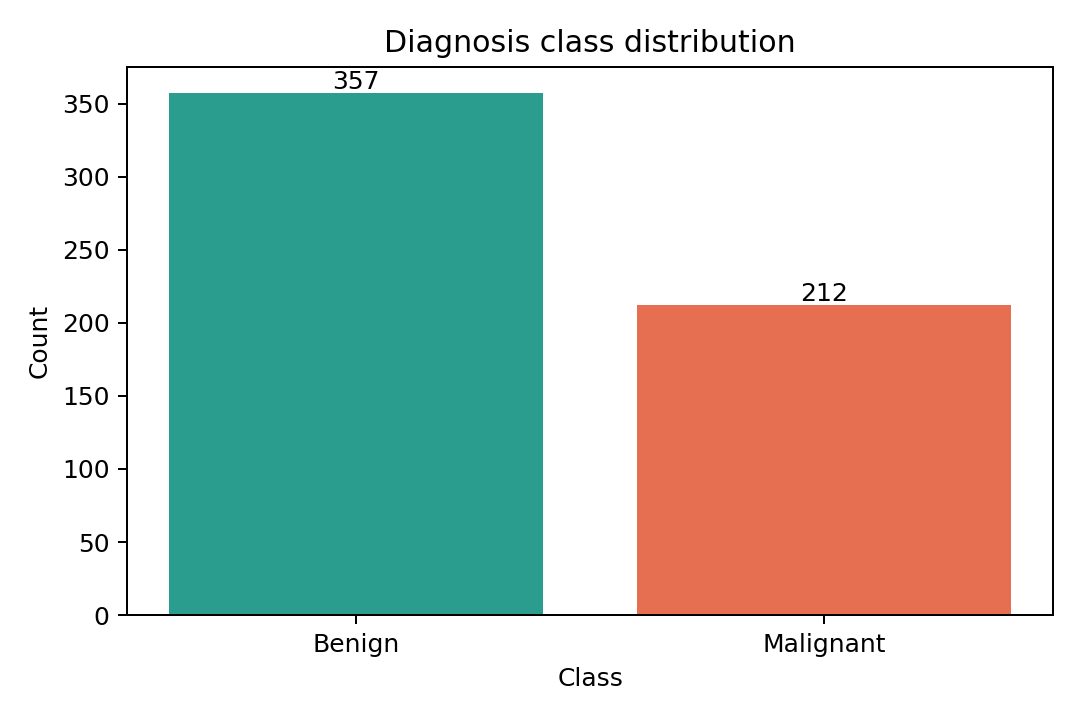

feature_correlation_heatmap.png


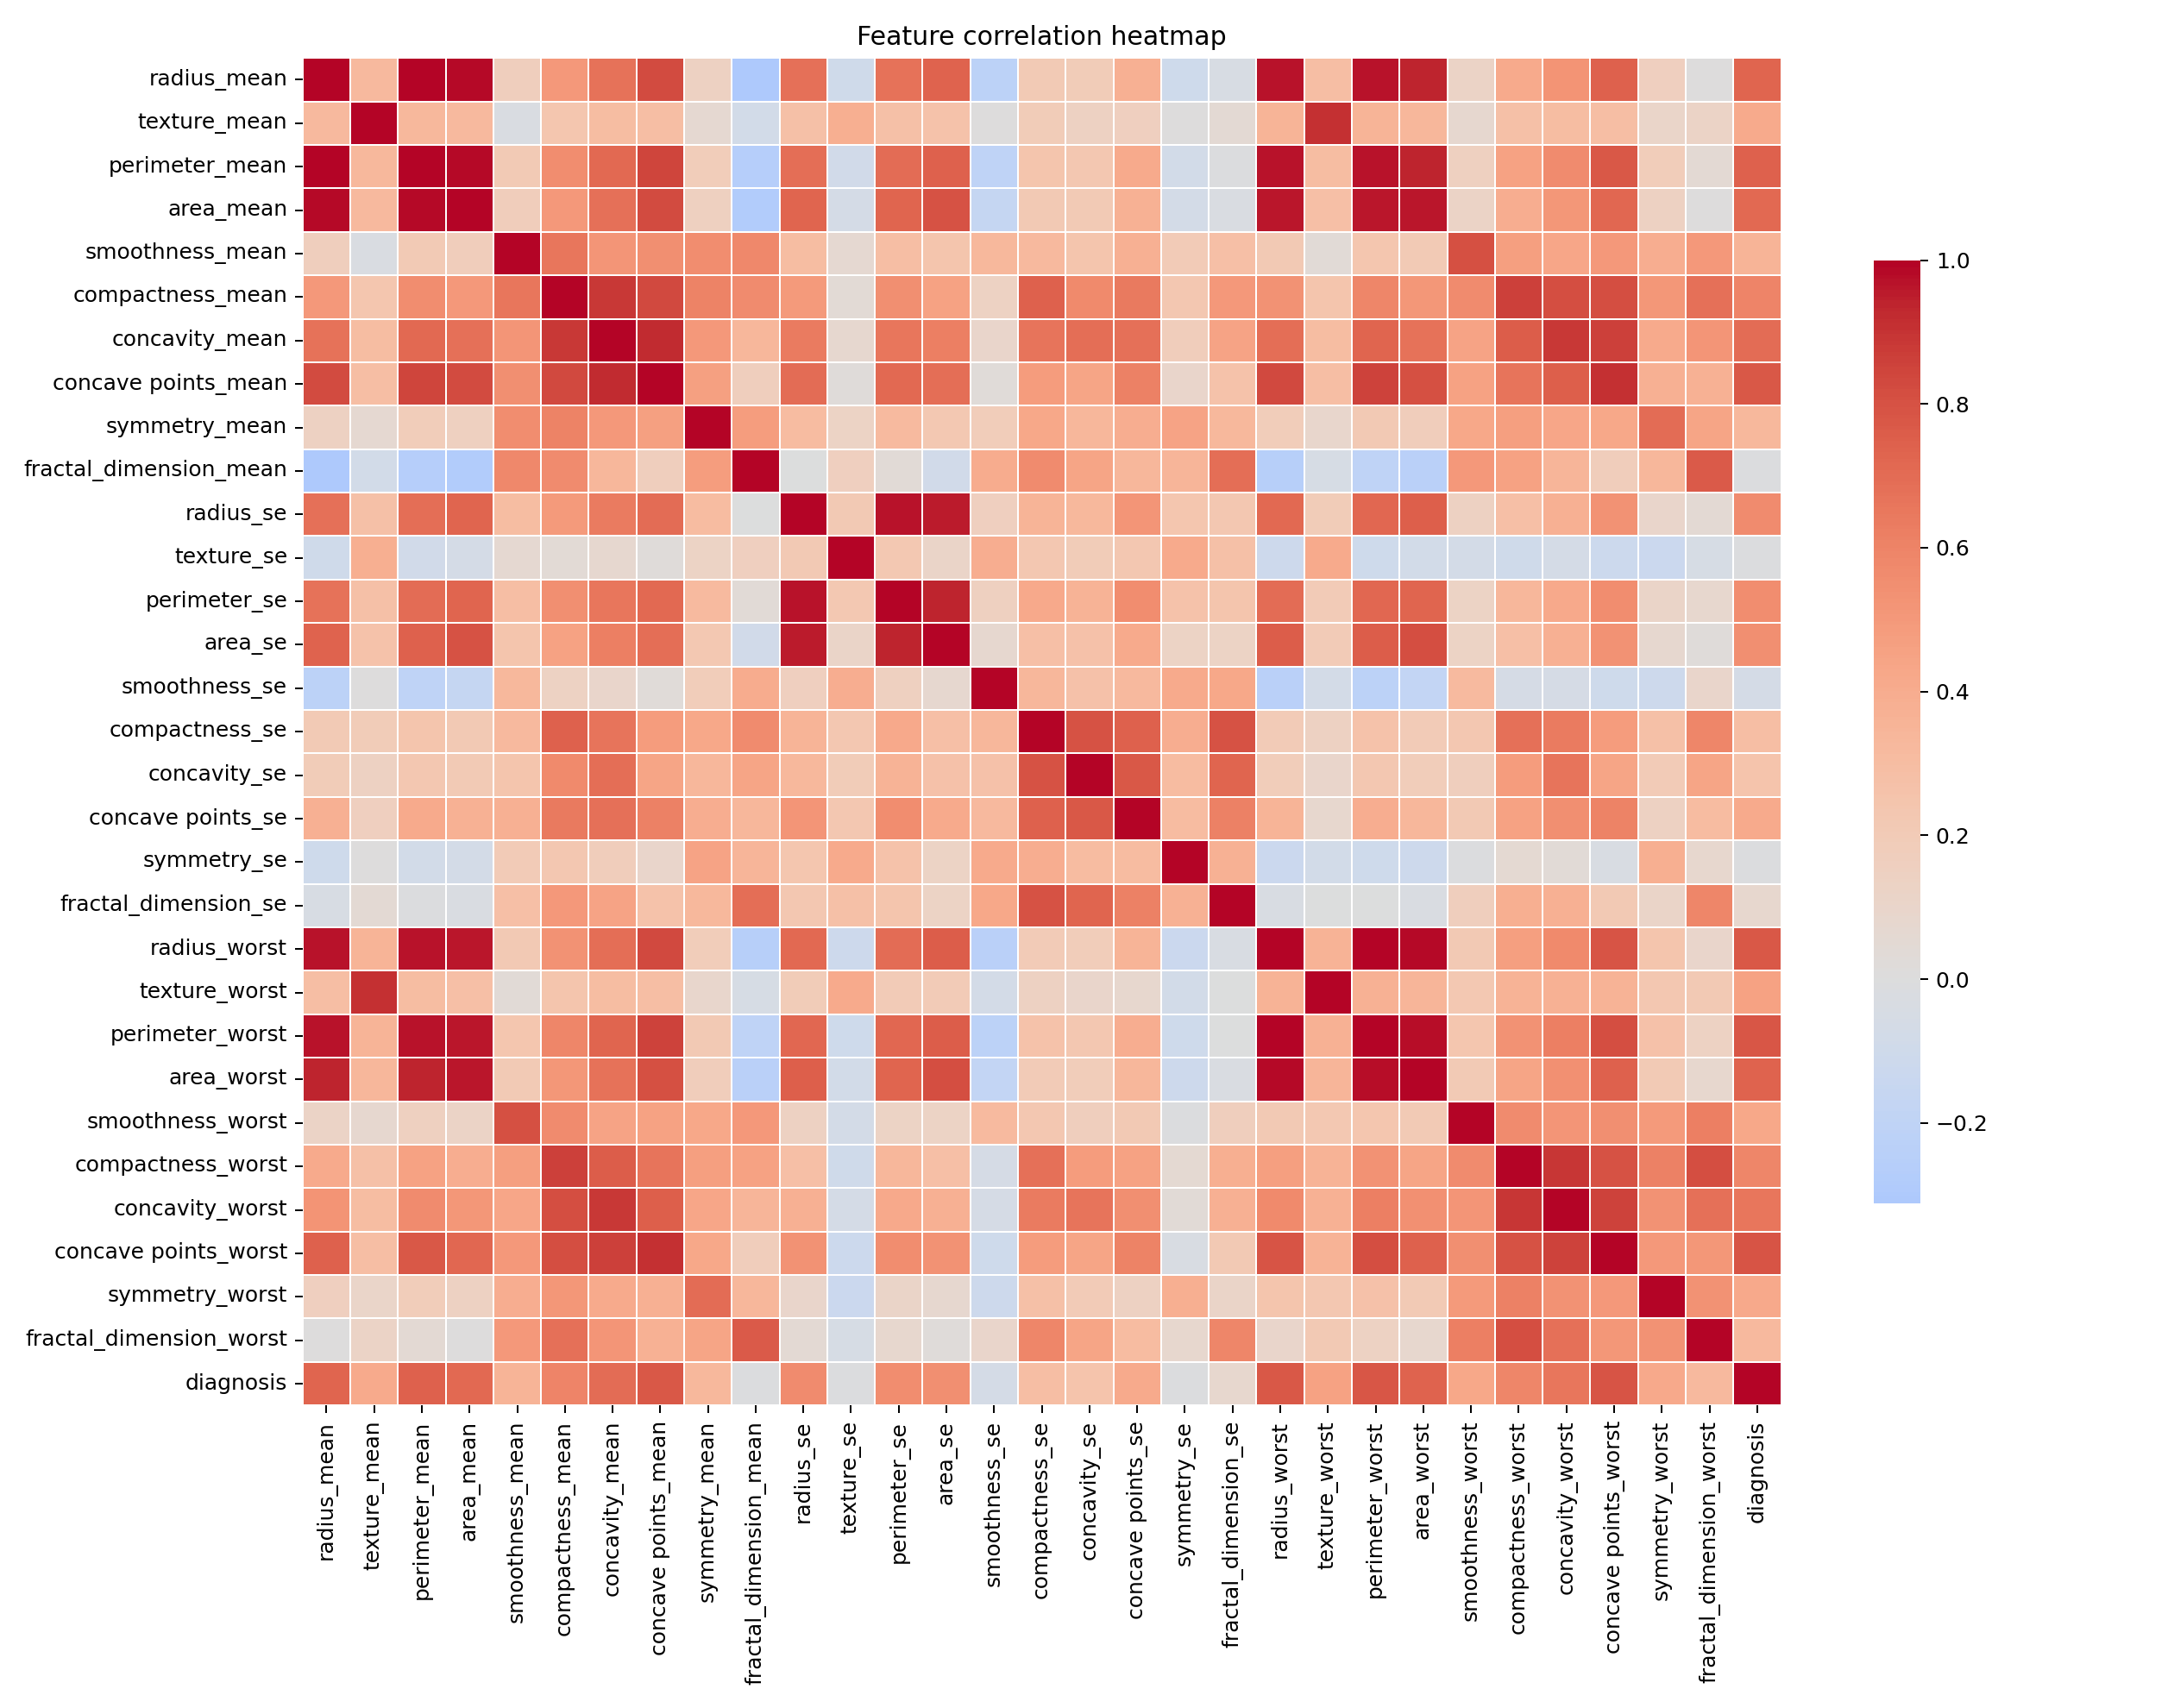

training_curves.png


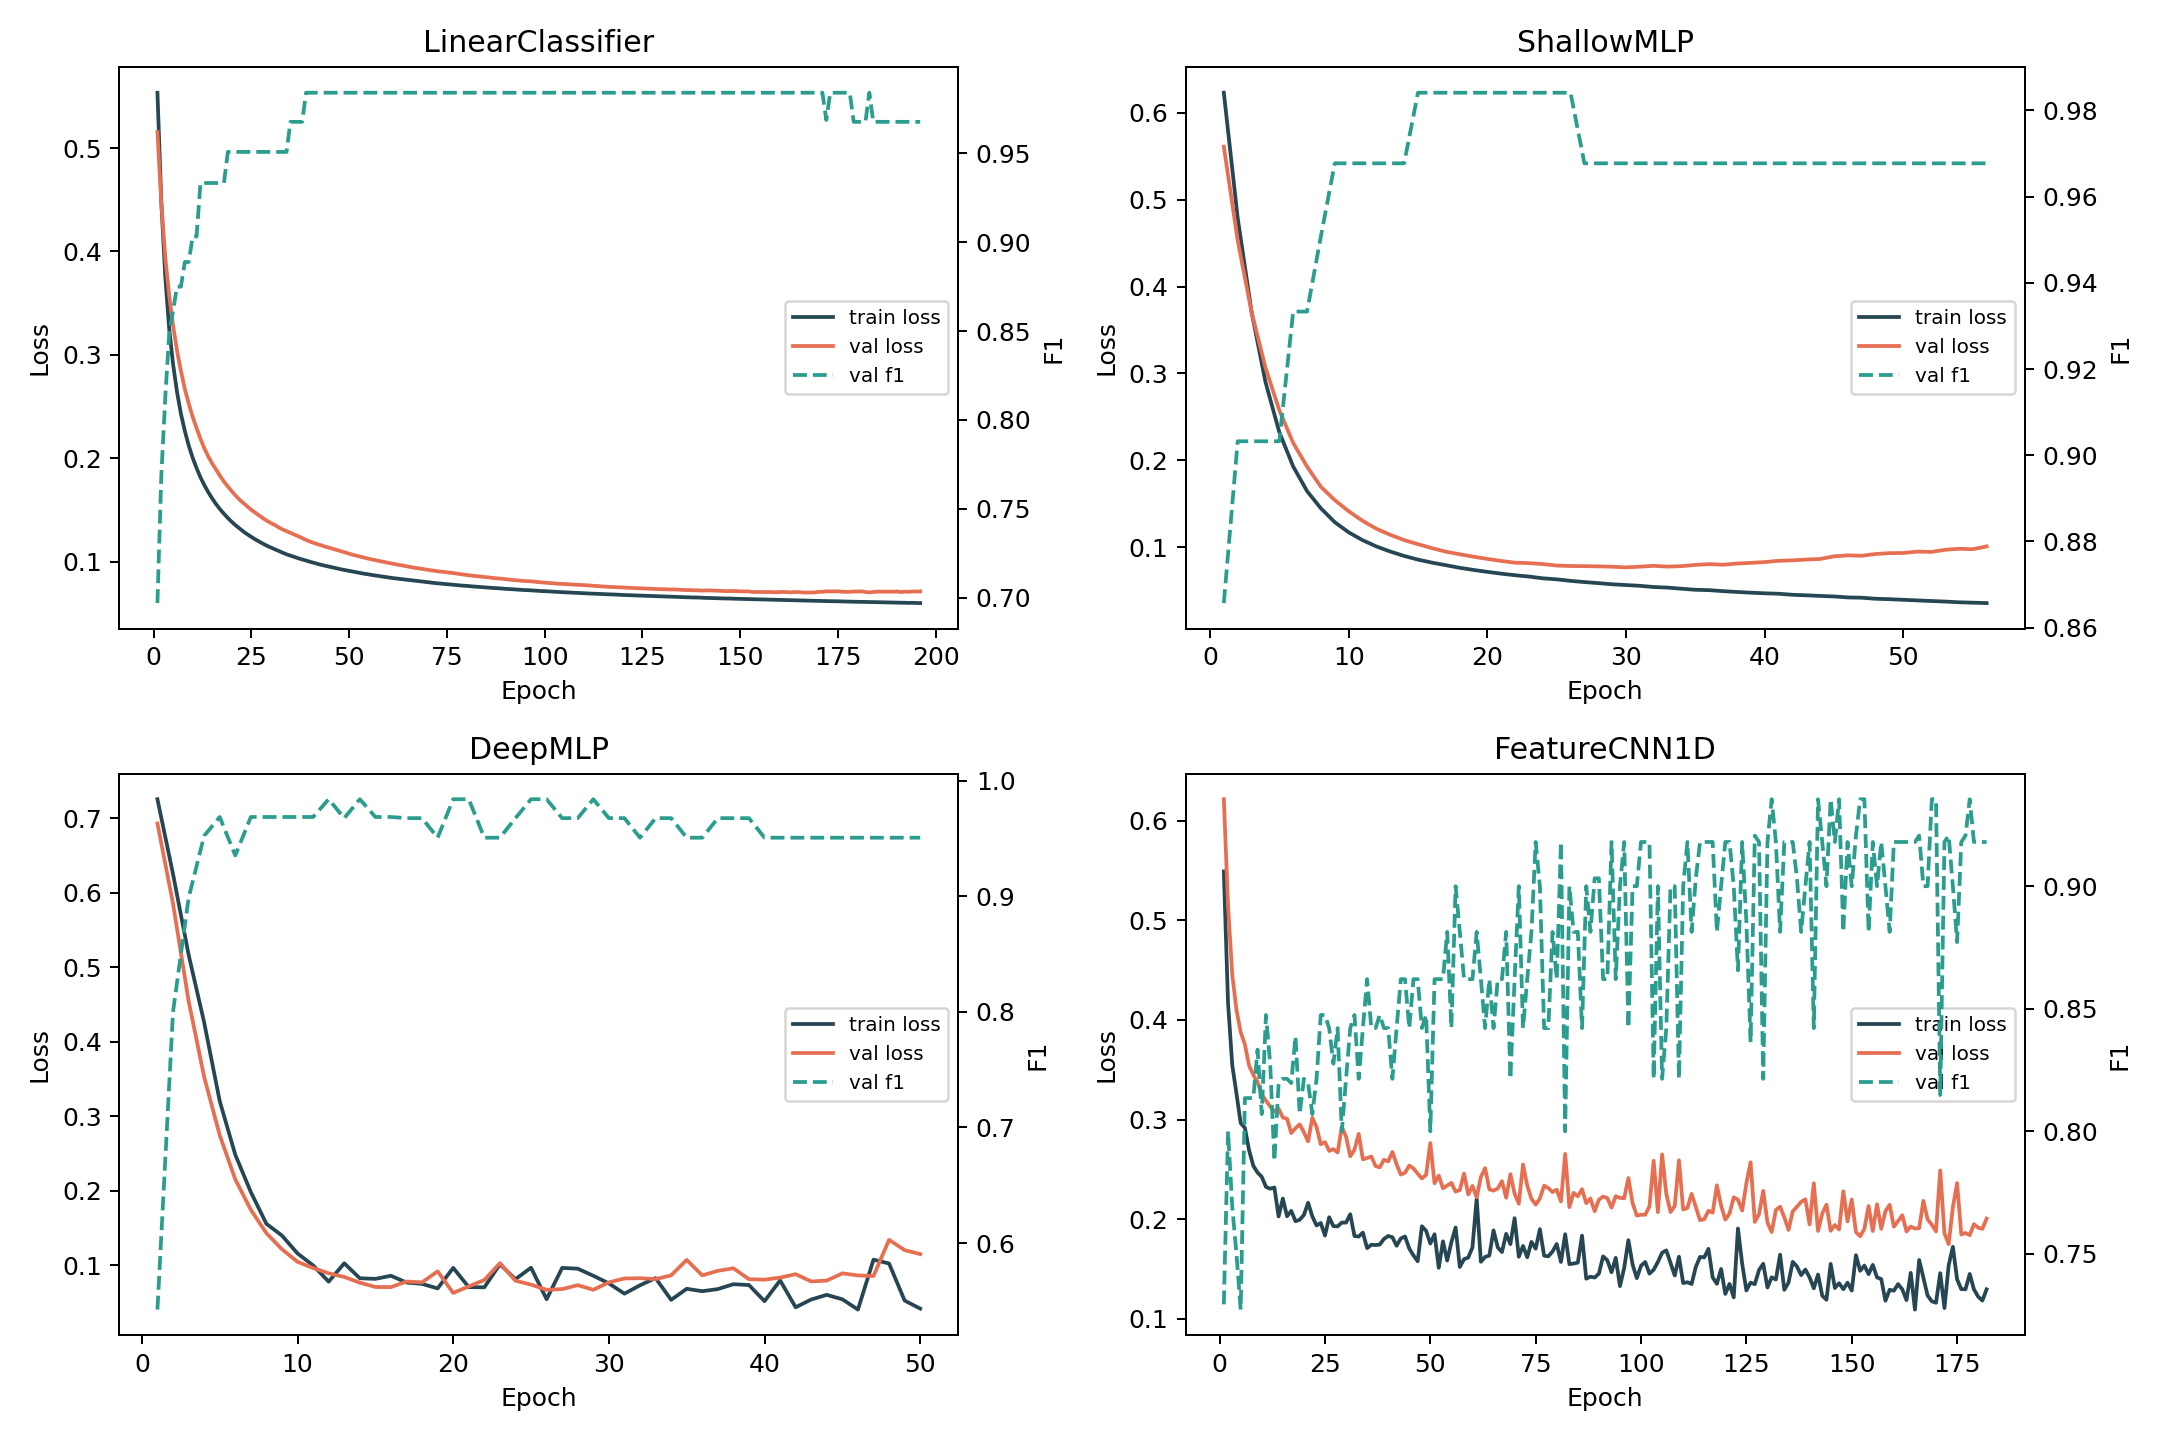

confusion_matrices.png


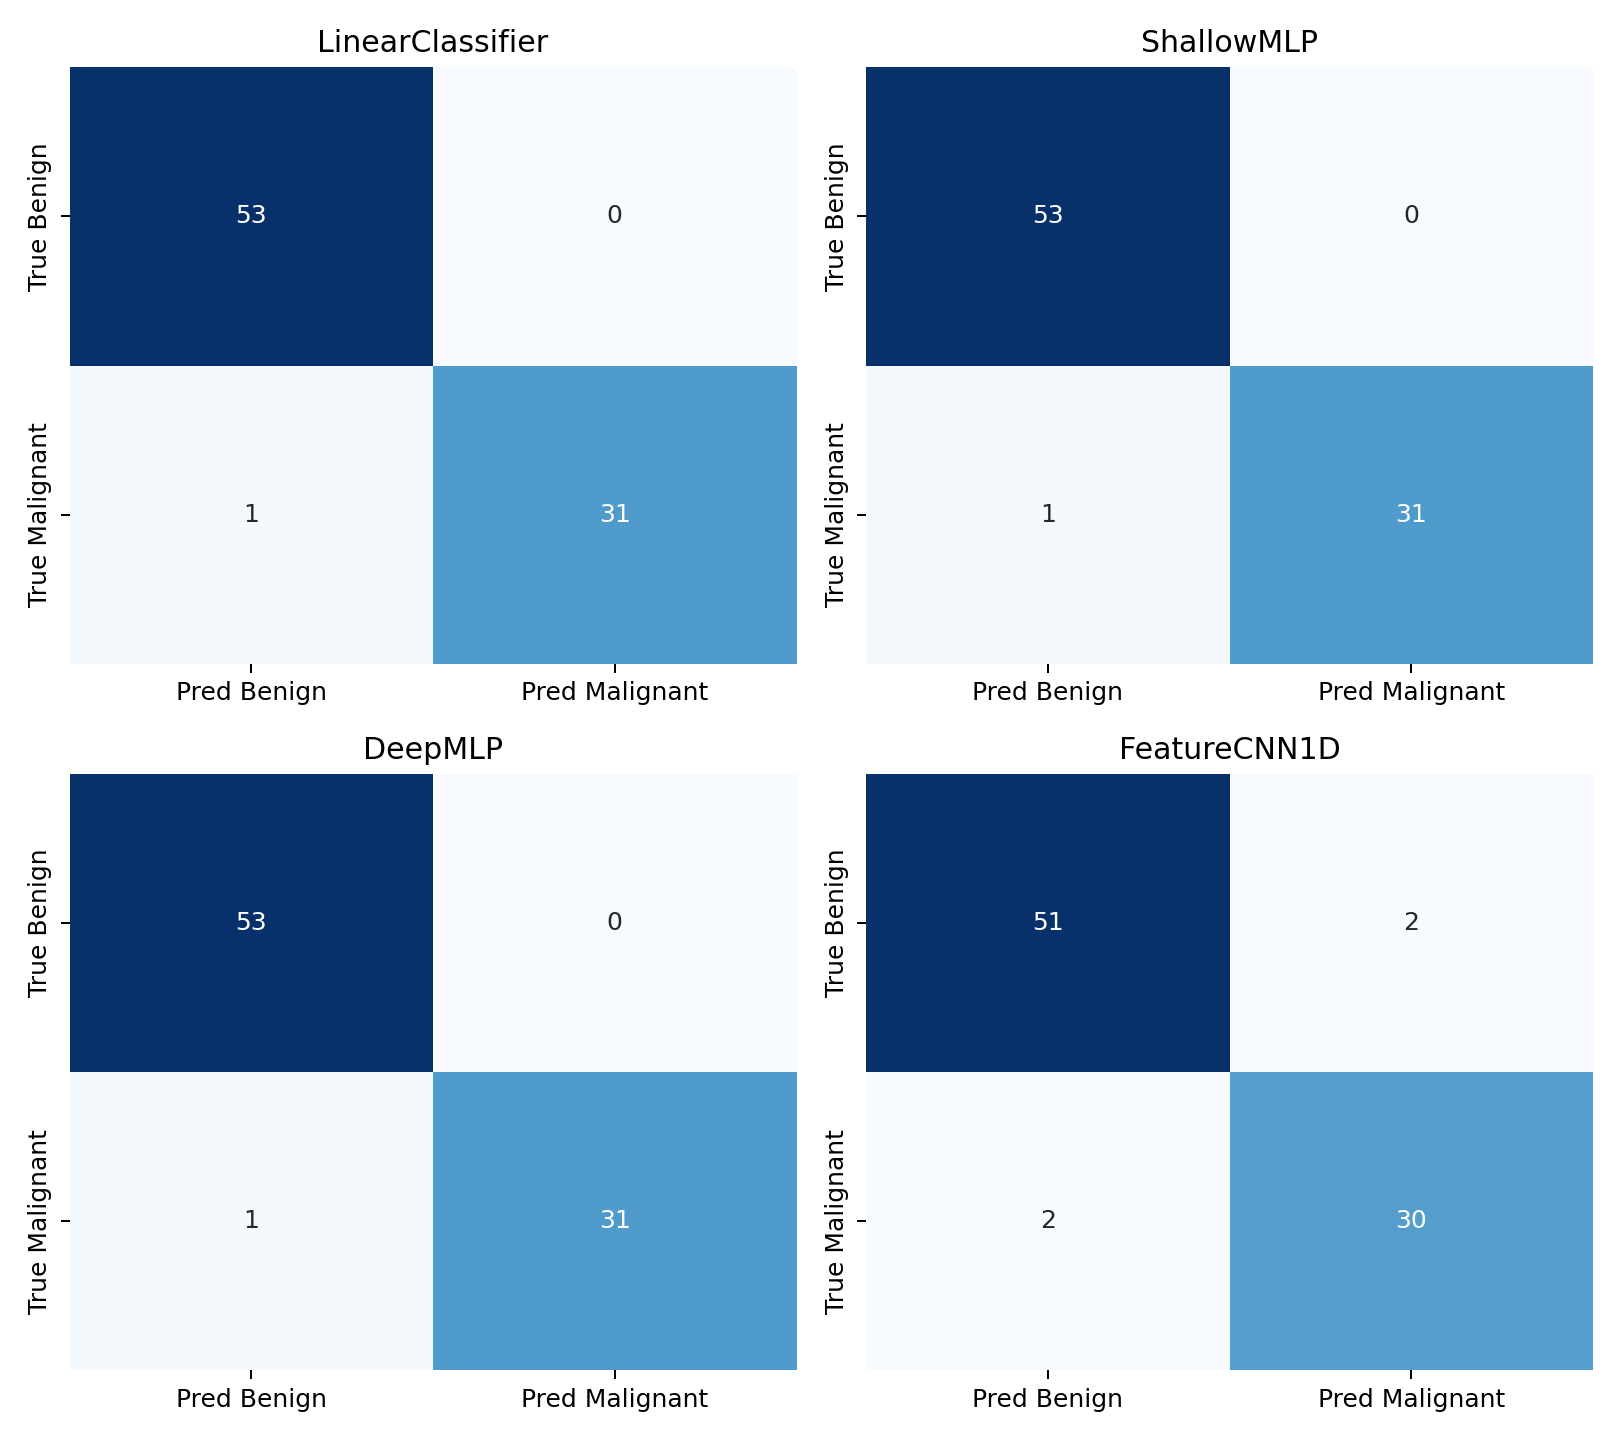

roc_curves.png


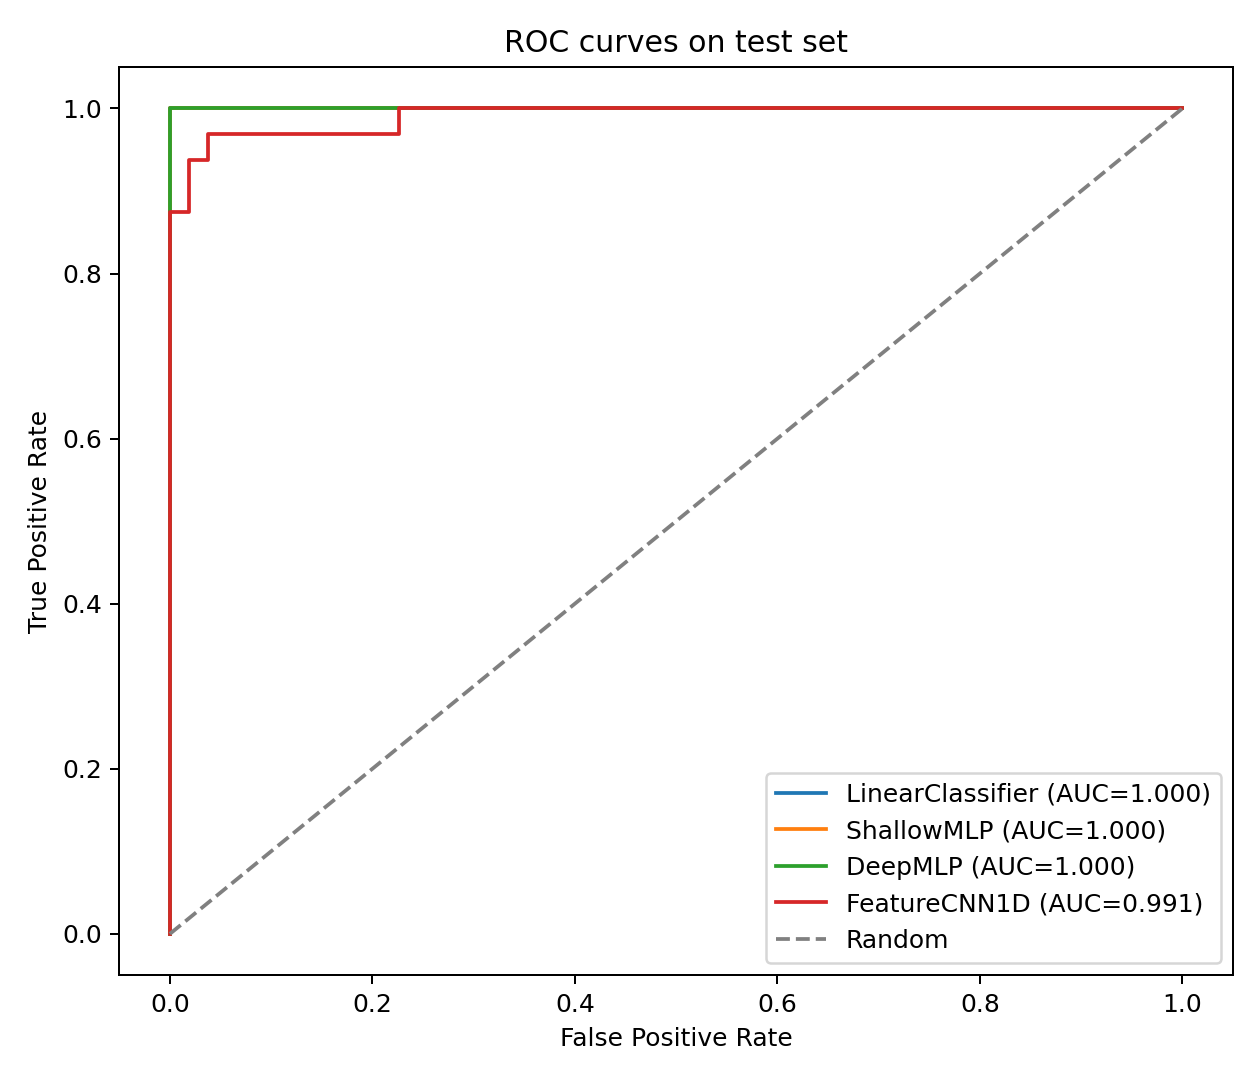

model_comparison.png


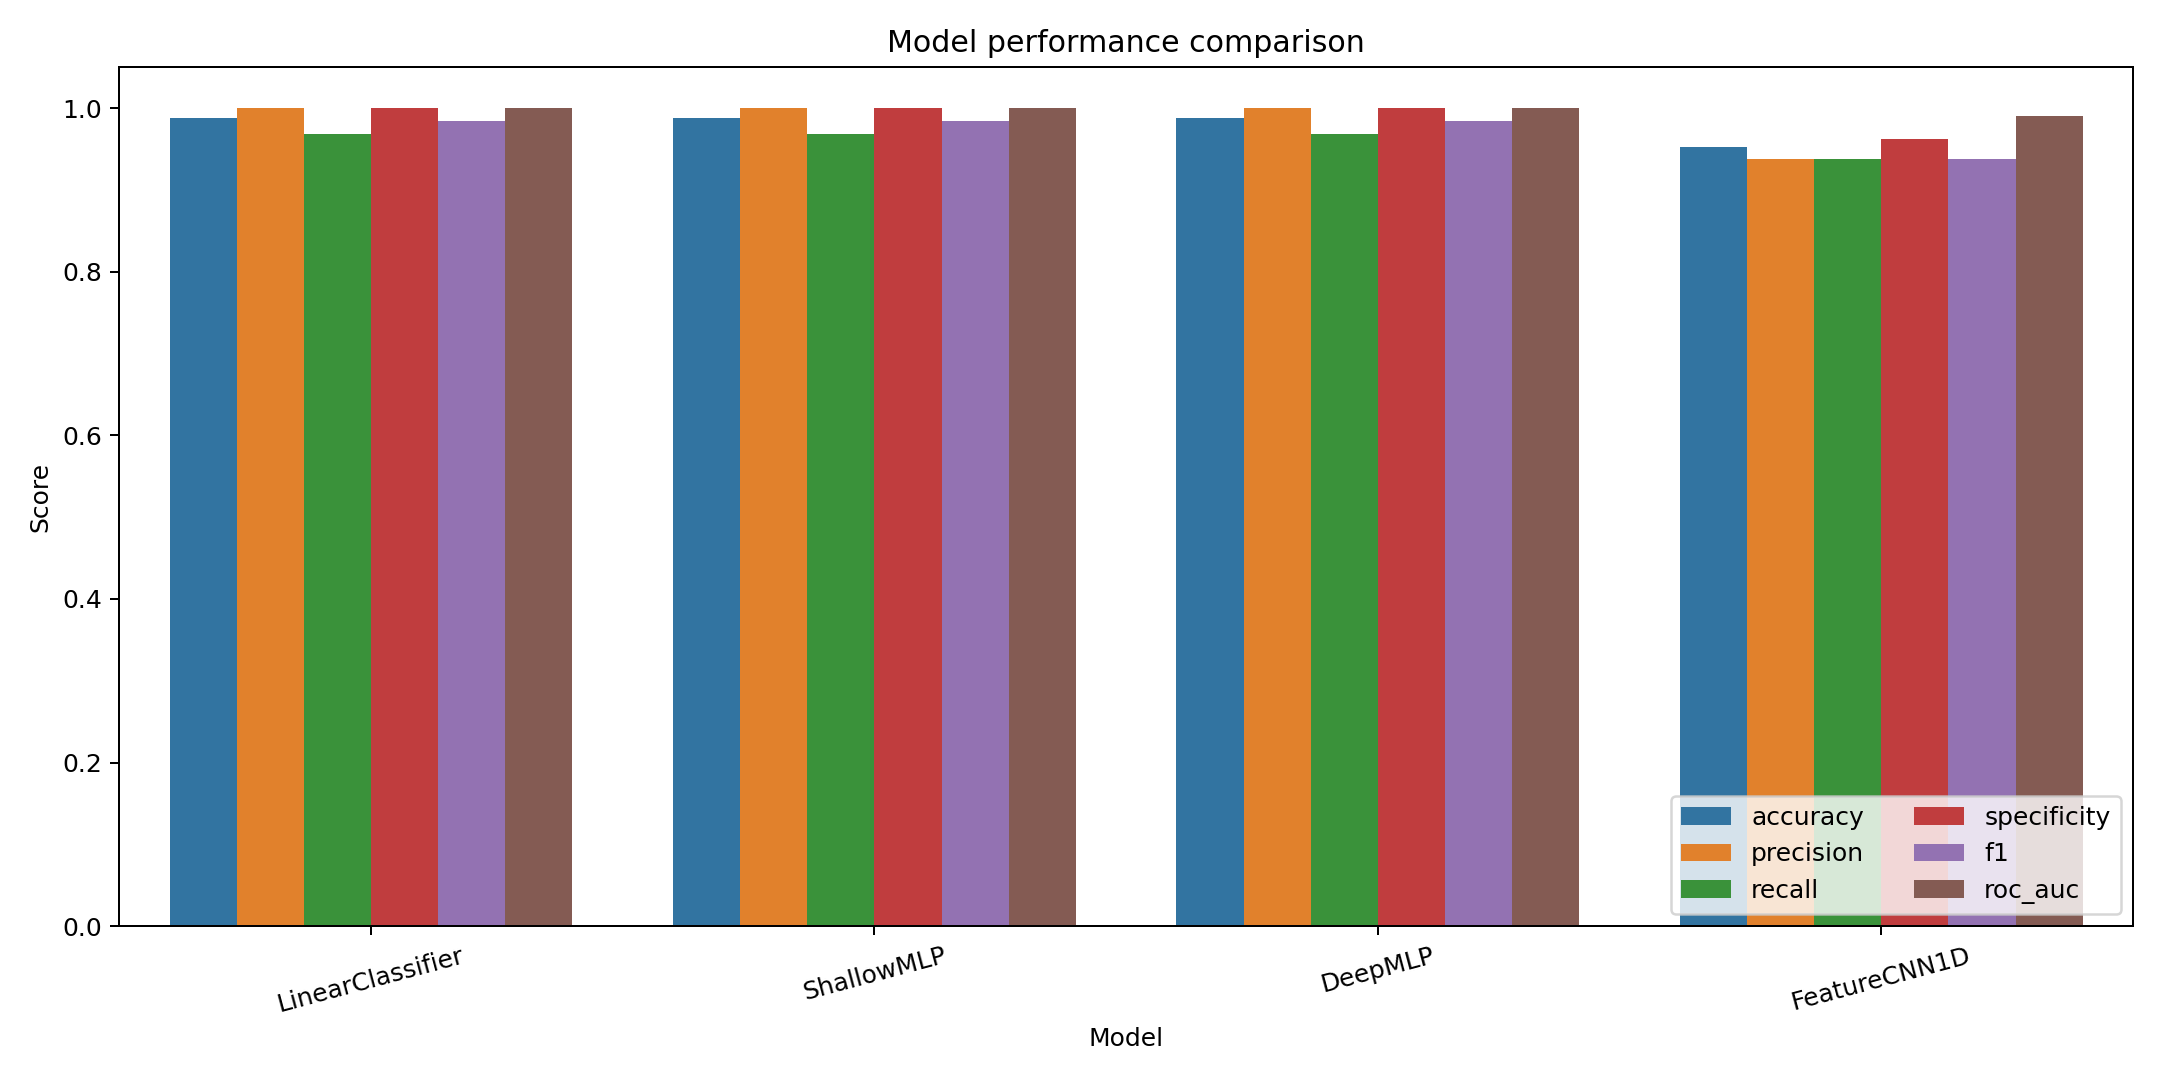

In [8]:
for filename in [
    'class_distribution.png',
    'feature_correlation_heatmap.png',
    'training_curves.png',
    'confusion_matrices.png',
    'roc_curves.png',
    'model_comparison.png',
]:
    print(filename)
    display(Image(filename=str(figure_dir / filename)))

## 7. 单样本预测示例

加载训练过程中选出的最佳模型，对数据集中第 0 行样本进行预测，输出良性概率和恶性概率。

In [9]:
sample = raw_df.iloc[0]
features = [float(sample[col]) for col in FEATURE_COLUMNS]
prediction = predict_features(
    features,
    model_path=results_dir / 'best_model.pt',
    stats_path=results_dir / 'preprocess_stats.json',
)
print('True label:', '恶性' if sample['diagnosis'] == 'M' else '良性')
prediction

True label: 恶性


{'prediction': 1,
 'prediction_en': 'Malignant',
 'prediction_zh': '恶性',
 'benign_probability': 5.732811203529309e-08,
 'malignant_probability': 1.0}

## 8. 实验结论

在本次固定划分的测试集上，线性分类器、浅层 MLP 和深层 MLP 都取得了较高的 F1-score 和 ROC-AUC，说明该数据集的 30 个统计特征对良恶性区分具有较强判别能力。一维卷积网络也能完成分类，但由于数据本质是表格特征，不具有明确的一维空间邻接关系，因此效果略低于 MLP 类模型。综合准确率、召回率、F1-score 与模型复杂度，线性分类器可作为稳定基线，MLP 可作为更具表达能力的神经网络方案。